# Mini-GPT desde cero · Tema 2 · Sesión 5

**Máster en Ingeniería de Automatización con IA Agéntica · EBIS**

En este notebook construimos un **GPT completo desde cero en ~150 líneas de PyTorch** y lo entrenamos sobre el texto íntegro de *Don Quijote de la Mancha*.

El objetivo no es competir con GPT-4, sino **entender exactamente qué ocurre por dentro**: tokenización, embeddings, atención, el bucle de entrenamiento y la generación autoregresiva. La diferencia con GPT-4 es de **escala**, no de naturaleza.

| | Nuestro mini-GPT | GPT-2 small | GPT-4 (estimado) |
|---|---|---|---|
| Parámetros | ~3 M | 117 M | ~1-2 T |
| Capas | 4 | 12 | ~120 |
| Contexto | 128 tokens | 1024 | 128 K |
| Tiempo de entrenamiento | 5-8 min | días | meses |
| Hardware | tu portátil | clúster de GPUs | miles de GPUs |

> Mismo plano arquitectónico. Distinta escala.

### Ruta del notebook (qué vamos a hacer, en orden)

1. **Preparar el entorno** — PyTorch y detección de dispositivo (CPU / GPU / Apple Silicon).
2. **Conseguir datos** — descargar el texto de *Don Quijote*.
3. **Tokenizar** — convertir texto en números (y entender *por qué* lo hacemos a nivel carácter).
4. **Formular la tarea** — predecir el siguiente token; preparar batches `input → target`.
5. **Construir el Transformer** — atención causal → multi-head → feed-forward → bloques → MiniGPT.
6. **Entrenar** — descenso de gradiente, y entender qué significa la *loss*.
7. **Mirar dentro** — mapas de atención y geometría de los embeddings.
8. **Generar** — comparar el modelo antes y después, y jugar con `temperature`, `top_k`, `top_p`.

Cada bloque tiene una celda de explicación (markdown) seguida de su celda de código. Lee la explicación, ejecuta el código, observa la salida.


## 0 · Compatibilidad de hardware (léeme primero)

Este notebook está pensado para ejecutarse en **cualquier ordenador**. El código detecta automáticamente el mejor dispositivo disponible:

- **CUDA** → GPU NVIDIA (Windows / Linux). El más rápido.
- **MPS** → GPUs de Apple Silicon (M1/M2/M3/M4). Muy rápido en Mac.
- **CPU** → cualquier máquina. Funciona siempre, pero más lento.

No tienes que cambiar nada: la celda de detección de dispositivo elige sola. Más abajo, en la configuración de hiperparámetros, encontrarás un interruptor `MODO_LIGERO` pensado para máquinas sin GPU, que reduce el tamaño del modelo para que el entrenamiento siga siendo de pocos minutos en CPU.

**Tiempos orientativos de entrenamiento (config por defecto, ~3 M de parámetros, 500 iteraciones):**

| Dispositivo | Tiempo aprox. |
|---|---|
| GPU NVIDIA (CUDA) | 1-3 min |
| Apple Silicon (MPS) | 5-8 min |
| CPU (config por defecto) | 20-40 min |
| CPU con `MODO_LIGERO = True` | 3-6 min |


## 1 · Instalación de dependencias

Necesitamos **PyTorch** (el modelo) y **matplotlib** (para las gráficas: mapa de atención, curva de entrenamiento y distribuciones de probabilidad). Si ya los tienes, puedes saltarte esta celda.

> Para GPU NVIDIA conviene instalar la build con CUDA siguiendo las instrucciones oficiales de https://pytorch.org. La instalación por defecto de `pip install torch` funciona en CPU y en Apple Silicon (MPS).


In [ ]:
# Descomenta la línea que corresponda a tu entorno y ejecútala una sola vez.

# CPU o Apple Silicon (Mac):
%pip install torch matplotlib

# GPU NVIDIA (ejemplo CUDA 12.1 — revisa https://pytorch.org para tu versión):
# %pip install torch --index-url https://download.pytorch.org/whl/cu121
# %pip install matplotlib

print("Si ya tienes PyTorch y matplotlib instalados, continúa con la siguiente celda.")

## 2 · Imports y semilla

Fijamos una semilla para que los resultados sean **reproducibles**: cada vez que ejecutes el notebook obtendrás el mismo entrenamiento.


In [48]:
import time
import math
import urllib.request
from pathlib import Path

import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(1337)
print("PyTorch:", torch.__version__)

PyTorch: 2.12.1


## 3 · Detección automática de dispositivo

**Esta es la celda que hace el notebook universal.** No depende de ningún hardware concreto: prueba CUDA, luego MPS, y si no hay ninguno usa la CPU. Funciona igual en un PC con GPU NVIDIA, en un MacBook con Apple Silicon o en un portátil sin GPU.


In [49]:
def elegir_dispositivo():
    """Devuelve el mejor dispositivo disponible: CUDA > MPS > CPU."""
    if torch.cuda.is_available():
        nombre = torch.cuda.get_device_name(0)
        print(f"✅ Usando CUDA (GPU NVIDIA): {nombre}")
        return torch.device("cuda")
    # getattr por compatibilidad con versiones antiguas de PyTorch sin backend mps
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        print("✅ Usando MPS (Apple Silicon)")
        return torch.device("mps")
    print("⚠️  No se ha detectado GPU. Usando CPU.")
    print("    El entrenamiento será más lento: activa MODO_LIGERO en la celda de config.")
    return torch.device("cpu")

device = elegir_dispositivo()
print("Dispositivo seleccionado:", device)

✅ Usando MPS (Apple Silicon)
Dispositivo seleccionado: mps


## 4 · Descargamos el corpus · Don Quijote

Usamos el texto íntegro de *Don Quijote* (dominio público, Project Gutenberg). Son ~2 MB de texto en español: suficiente para que el modelo aprenda sintaxis, vocabulario y un estilo cervantino reconocible, y lo bastante pequeño para entrenar en minutos.

Si la descarga falla (sin internet, por ejemplo), la celda te lo indica: basta con colocar manualmente un fichero de texto llamado `quijote.txt` junto al notebook.


In [50]:
RUTA_TEXTO = Path("quijote.txt")
URL_QUIJOTE = "https://www.gutenberg.org/cache/epub/2000/pg2000.txt"

if RUTA_TEXTO.exists():
    print(f"Ya existe {RUTA_TEXTO} — no se vuelve a descargar.")
else:
    try:
        print("Descargando Don Quijote desde Project Gutenberg...")
        urllib.request.urlretrieve(URL_QUIJOTE, RUTA_TEXTO)
        print("Descarga completada.")
    except Exception as e:
        print("No se pudo descargar automáticamente:", e)
        print("Coloca manualmente un fichero de texto llamado 'quijote.txt' junto a este notebook.")

texto = RUTA_TEXTO.read_text(encoding="utf-8", errors="ignore")
print(f"\nLongitud del corpus: {len(texto):,} caracteres")
print("\n--- Fragmento ---")
print(texto[2000:2500])

Ya existe quijote.txt — no se vuelve a descargar.

Longitud del corpus: 2,130,057 caracteres

--- Fragmento ---
a don Quijote con el vizcaíno, y
del peligro en que se vio con una turba de yangüeses

De lo que le sucedió a don Quijote con unos
cabreros

De lo que contó un cabrero a los que estaban con don
Quijote

Donde se da fin al cuento de la pastora Marcela, con
otros sucesos

Donde se ponen los versos desesperados del difunto
pastor, con otros no esperados sucesos

Donde se cuenta la desgraciada aventura que se topó
don Quijote en topar con unos desalmados yangüeses

De lo que le sucedió al ingenioso 


## 5 · ¿Qué es "tokenizar"? Y por qué aquí lo hacemos a nivel carácter

Una red neuronal no entiende letras: solo opera con **números**. Tokenizar es el primer paso de *todo* LLM y consiste en dos cosas:

1. **Trocear** el texto en unidades llamadas *tokens*.
2. **Asignar a cada token un número entero** (su ID) mediante un vocabulario.

¿De qué tamaño hacemos los trozos? Hay tres granularidades habituales:

| Granularidad | "Don Quijote" se parte en… | Tamaño del vocabulario | Longitud de la secuencia |
|---|---|---|---|
| **Carácter** (lo que usamos aquí) | `D · o · n · ␣ · Q · u · i · j · o · t · e` (11) | ~100 símbolos | muy larga |
| **Subpalabra / BPE** (GPT-2/3/4) | `Don · ␣Qu · ij · ote` (≈4) | 50 000 – 100 000 | media |
| **Palabra** | `Don · Quijote` (2) | cientos de miles | corta |

**El compromiso central:** vocabulario pequeño ⇄ secuencias largas.

- **Carácter:** vocabulario minúsculo, pero el modelo necesita muchos pasos (muchos tokens) para el mismo texto y debe aprender *hasta la ortografía*.
- **Palabra:** secuencias cortas, pero el vocabulario explota y cualquier palabra rara, mal escrita o inventada se queda fuera (token "desconocido").
- **BPE (Byte Pair Encoding):** el punto medio que usan los GPT reales. Parte de caracteres y va **fusionando los pares más frecuentes** hasta formar sub-palabras. Así, las palabras comunes son 1 token, las raras se descomponen en piezas conocidas y **nunca** hay un token "desconocido". Regla mental: ~1 token ≈ 4 caracteres.

### Entonces, ¿por qué este notebook usa caracteres?

Por **didáctica**, no por calidad. A nivel carácter:

1. **El tokenizador cabe en 5 líneas que puedes leer enteras** — sin librerías externas ni algoritmos opacos.
2. **El vocabulario es de ~100 símbolos**, así que la tabla de embeddings y la capa de salida son pequeñas y el modelo entrena en minutos.
3. **Verás al modelo aprender a deletrear desde cero:** empieza escupiendo símbolos al azar y termina formando palabras, puntuación y frases. Ese "milagro" es mucho más visible que con BPE.
4. **La arquitectura del Transformer es idéntica.** Cambiar a BPE solo cambia `vocab_size` y el tamaño de *dos* capas (el embedding de entrada y la proyección de salida). El resto —atención, bloques, bucle de entrenamiento, generación— no se toca. **Cambiar de tokenizador es, literalmente, sustituir las funciones `encode` / `decode`.**

> Lo único que "pagamos": como cada carácter es un token, nuestro contexto de 128 tokens equivale a ~25 palabras; para GPT-4 esos mismos 128 tokens serían ~100 palabras. Misma idea, distinta densidad.

Veámoslo de forma concreta en la siguiente celda 👇


In [51]:
muestra = "En un lugar de la Mancha, de cuyo nombre no quiero acordarme"

# 1) A nivel CARÁCTER (lo que hace este notebook)
chars_tok = list(muestra)
print(f"CARÁCTER  -> {len(chars_tok):2d} tokens")
print("           ", chars_tok[:18], "...")

# 2) A nivel PALABRA (aproximado, partiendo por espacios)
palabras = muestra.split()
print(f"\nPALABRA   -> {len(palabras):2d} tokens")
print("           ", palabras)

# 3) A nivel SUBPALABRA (BPE real de GPT-4), solo si tienes 'tiktoken' instalado
try:
    import tiktoken
    enc = tiktoken.get_encoding("cl100k_base")   # el tokenizador de GPT-4
    ids = enc.encode(muestra)
    piezas = [enc.decode([i]) for i in ids]
    print(f"\nBPE (GPT-4) -> {len(ids):2d} tokens")
    print("           ", piezas)
except Exception:
    print("\nBPE (GPT-4) -> instala 'tiktoken' para verlo:  %pip install tiktoken")

print("\nMisma frase, distinto número de tokens según la granularidad.")
print("Menos tokens por frase = secuencias más cortas, pero vocabulario más grande.")


CARÁCTER  -> 60 tokens
            ['E', 'n', ' ', 'u', 'n', ' ', 'l', 'u', 'g', 'a', 'r', ' ', 'd', 'e', ' ', 'l', 'a', ' '] ...

PALABRA   -> 12 tokens
            ['En', 'un', 'lugar', 'de', 'la', 'Mancha,', 'de', 'cuyo', 'nombre', 'no', 'quiero', 'acordarme']

BPE (GPT-4) -> 17 tokens
            ['En', ' un', ' lugar', ' de', ' la', ' Man', 'cha', ',', ' de', ' c', 'uyo', ' nombre', ' no', ' quiero', ' ac', 'ord', 'arme']

Misma frase, distinto número de tokens según la granularidad.
Menos tokens por frase = secuencias más cortas, pero vocabulario más grande.


## 6 · Nuestro tokenizador de caracteres

Ya sabemos *por qué* vamos a nivel carácter. Construirlo es muy simple:

- El **vocabulario** son los caracteres únicos que aparecen en el texto (`~100`).
- `stoi` (*string → int*) e `itos` (*int → string*) son los dos diccionarios que traducen carácter ↔ ID.
- `encode` convierte texto en una lista de enteros; `decode` hace lo inverso.

Fíjate en que **no hay nada que "entrenar"** en el tokenizador: es un simple diccionario.


In [52]:
chars = sorted(list(set(texto)))
vocab_size = len(chars)
print(f"Vocabulario: {vocab_size} caracteres únicos")
print("".join(chars))

stoi = {ch: i for i, ch in enumerate(chars)}   # string -> int
itos = {i: ch for i, ch in enumerate(chars)}   # int -> string

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join([itos[i] for i in l])

# Comprobación rápida
print("\nencode('Quijote') =", encode("Quijote"))
print("decode(...)        =", decode(encode("Quijote")))

Vocabulario: 110 caracteres únicos

 !"#$%'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]abcdefghijklmnopqrstuvwxyz¡«»¿ÁÉÍÑÓÚàáéíïñóùúü—‘’“”•™

encode('Quijote') = [45, 77, 65, 66, 71, 76, 61]
decode(...)        = Quijote


## 7 · Codificamos el corpus y dividimos en train / val

Convertimos **todo** el texto en un único tensor gigante de IDs. Reservamos el 90 % para entrenamiento y el 10 % para validación.

¿Por qué separar? Porque queremos detectar **sobreajuste** (*overfitting*): si la *loss* de entrenamiento baja pero la de validación se estanca o sube, el modelo está **memorizando** el texto en lugar de **aprender patrones generales** del lenguaje. La partición de validación es texto que el modelo *nunca usa para actualizar sus pesos*, así que es un juez honesto.


In [53]:
data = torch.tensor(encode(texto), dtype=torch.long)
print("Tensor de datos:", data.shape, data.dtype)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"Train: {len(train_data):,} tokens | Val: {len(val_data):,} tokens")

Tensor de datos: torch.Size([2130057]) torch.int64
Train: 1,917,051 tokens | Val: 213,006 tokens


## 8 · Hiperparámetros

Aquí vive la configuración del modelo. Los valores por defecto producen un modelo de **~3 millones de parámetros**, ideal para Apple Silicon (MPS) o GPU.

Si estás en una **máquina sin GPU**, pon `MODO_LIGERO = True`: reduce el tamaño del modelo y el número de iteraciones para que el entrenamiento siga durando pocos minutos en CPU. El modelo resultante genera texto algo menos pulido, pero el proceso de aprendizaje se ve igual de bien.

Qué controla cada cosa (intuición rápida):

- `n_embed` — el "ancho" del modelo: cuántos números describen a cada token. Más ancho = más capacidad.
- `n_head` — cuántas cabezas de atención miran el contexto en paralelo.
- `n_layer` — cuántos bloques Transformer apilamos (la "profundidad").
- `block_size` — el **contexto**: cuántos tokens hacia atrás puede mirar el modelo.
- `batch_size` — cuántas secuencias procesamos a la vez en cada paso.
- `learning_rate` — el tamaño del paso al actualizar los pesos.


In [54]:
# === Interruptor para máquinas sin GPU ===
MODO_LIGERO = False   # ponlo en True si entrenas en CPU

# Ajuste automático: si no hay GPU, sugerimos modo ligero
if device.type == "cpu" and not MODO_LIGERO:
    print("⚠️  Estás en CPU con la config completa. El entrenamiento puede tardar 20-40 min.")
    print("    Considera poner MODO_LIGERO = True para ~3-6 min.")

if MODO_LIGERO:
    n_embed    = 128   # dimensiones de embedding
    n_head     = 4     # cabezas de atención
    n_layer    = 3     # bloques Transformer
    block_size = 64    # tokens de contexto
    max_iters  = 2000
    batch_size = 32
else:
    n_embed    = 256
    n_head     = 4
    n_layer    = 4
    block_size = 128
    max_iters  = 5000
    batch_size = 64

# Comunes
learning_rate = 3e-4
eval_interval = 250
eval_iters    = 50
dropout       = 0.1

print(f"Config -> n_embed={n_embed}, n_head={n_head}, n_layer={n_layer}, "
      f"block_size={block_size}, max_iters={max_iters}, batch_size={batch_size}")

Config -> n_embed=256, n_head=4, n_layer=4, block_size=128, max_iters=5000, batch_size=64


## 9 · La tarea: predecir el siguiente token

Todo el entrenamiento de un GPT se reduce a **una sola tarea**: dado un trozo de texto, predecir el **siguiente** token. No hay etiquetas hechas por humanos; el "profesor" es el propio texto, que ya contiene la respuesta correcta (el carácter que viene después). A esto se le llama aprendizaje **auto-supervisado**.

Para cada paso de entrenamiento extraemos `batch_size` secuencias aleatorias de longitud `block_size` y construimos el par:

- **input** `x`: tokens en las posiciones `0 … N-1`
- **target** `y`: los mismos tokens **desplazados una posición**, `1 … N`

Así, cuando el modelo ve `x` hasta la posición *t*, su objetivo es predecir `y[t]` (que es justo `x[t+1]`). Eso es todo lo que hace un modelo de lenguaje.


In [55]:
def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

# Inspeccionamos un batch
xb, yb = get_batch("train")
print("input  (x):", xb.shape)
print("target (y):", yb.shape)
print("\nEjemplo — input :", repr(decode(xb[0].tolist())[:50]))
print("Ejemplo — target:", repr(decode(yb[0].tolist())[:50]))

input  (x): torch.Size([64, 128])
target (y): torch.Size([64, 128])

Ejemplo — input : 'ás\nque hacer sino que, cuando vieres que en alguna'
Ejemplo — target: 's\nque hacer sino que, cuando vieres que en alguna '


### Una sola secuencia son muchos ejemplos a la vez

Aquí hay un detalle clave de eficiencia. Gracias a la **máscara causal** (que veremos en la atención), dentro de una secuencia de longitud `block_size` el modelo predice en **todas** las posiciones a la vez: en la posición 0 ve 1 token y predice el 2º; en la posición 1 ve 2 tokens y predice el 3º; y así sucesivamente.

Es decir, **una secuencia de 128 tokens son 128 ejemplos de entrenamiento simultáneos**. Vamos a desplegar las primeras predicciones de una secuencia para verlo con claridad:


In [56]:
inicio = 2000                                          # un punto cualquiera ya dentro del texto en español
ejemplo = train_data[inicio:inicio + block_size + 1]   # una secuencia + 1 token (el último target)

print("A partir de UNA secuencia, el modelo aprende todas estas predicciones:\n")
for t in range(8):                       # mostramos solo las 8 primeras posiciones
    contexto = ejemplo[:t + 1]
    objetivo = ejemplo[t + 1]
    print(f"  ve {repr(decode(contexto.tolist())):22}  ->  debe predecir {repr(decode([objetivo.item()]))}")

print(f"\n...y así hasta la posición {block_size}.  ->  1 secuencia = {block_size} ejemplos de 'predice el siguiente'.")
print(f"Con batch_size={batch_size}, cada paso de entrenamiento son {batch_size * block_size:,} predicciones.")


A partir de UNA secuencia, el modelo aprende todas estas predicciones:

  ve 'a'                     ->  debe predecir ' '
  ve 'a '                    ->  debe predecir 'd'
  ve 'a d'                   ->  debe predecir 'o'
  ve 'a do'                  ->  debe predecir 'n'
  ve 'a don'                 ->  debe predecir ' '
  ve 'a don '                ->  debe predecir 'Q'
  ve 'a don Q'               ->  debe predecir 'u'
  ve 'a don Qu'              ->  debe predecir 'i'

...y así hasta la posición 128.  ->  1 secuencia = 128 ejemplos de 'predice el siguiente'.
Con batch_size=64, cada paso de entrenamiento son 8,192 predicciones.


## 10 · La arquitectura, pieza a pieza

Ahora construimos el Transformer **de abajo arriba**. Esta es la vista general del recorrido de los datos:

```
 IDs de tokens
      │
      ▼
 [token embedding] + [position embedding]      ← cada token se convierte en un vector, y le sumamos "dónde está"
      │
      ▼
 ┌─────────────  Bloque Transformer  (× n_layer)  ─────────────┐
 │   x = x + AtenciónMultiCabeza( LayerNorm(x) )   ← los tokens "se hablan" entre sí
 │   x = x + FeedForward( LayerNorm(x) )           ← cada token "piensa" por su cuenta
 └─────────────────────────────────────────────────────────────┘
      │
      ▼
 [LayerNorm final] → [capa lineal de salida]
      │
      ▼
 logits: una puntuación por cada token del vocabulario  ← "¿cuál es el siguiente?"
```

Lo construiremos en este orden:

1. **`Head`** — una única cabeza de auto-atención (self-attention) causal.
2. **`MultiHeadAttention`** — varias cabezas en paralelo, concatenadas.
3. **`FeedForward`** — una pequeña red densa que procesa cada posición.
4. **`Block`** — atención + feed-forward, con conexiones residuales y LayerNorm.
5. **`MiniGPT`** — embeddings + N bloques + cabeza de salida.

La pieza nueva y central es la **atención**. Antes de ver su código, entendamos la intuición.


### 10.1 · La intuición de la atención: una media (ponderada) del pasado

¿Qué *calcula* en el fondo la atención? Cada token construye su nueva representación **combinando información de los tokens anteriores** (no puede mirar al futuro: es **causal**).

El caso más simple de "combinar el pasado" es **promediarlo**. Y resulta que promediar el pasado se puede escribir como **multiplicar por una matriz triangular de pesos**. Mira este ejemplo de juguete:


In [57]:
import torch

torch.manual_seed(1337)
T = 5                                  # 5 posiciones de ejemplo
tril = torch.tril(torch.ones(T, T))    # matriz triangular inferior de 1s
wei  = tril / tril.sum(dim=1, keepdim=True)   # normalizamos cada fila -> pesos que suman 1

print("Pesos 'wei' (cada fila = cuánto pesa cada token del pasado para la posición t):\n")
print(wei)
print("\nLectura por filas:")
print(" . fila 0: la posicion 0 solo se ve a si misma            -> [1.00, 0, 0, 0, 0]")
print(" . fila 1: la posicion 1 promedia las posiciones 0 y 1    -> [0.50, 0.50, 0, 0, 0]")
print(" . fila 4: la posicion 4 promedia las posiciones 0..4     -> [0.20, 0.20, 0.20, 0.20, 0.20]")
print("\nLos CEROS del triangulo superior = 'prohibido mirar al futuro' (mascara causal).")


Pesos 'wei' (cada fila = cuánto pesa cada token del pasado para la posición t):

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000]])

Lectura por filas:
 . fila 0: la posicion 0 solo se ve a si misma            -> [1.00, 0, 0, 0, 0]
 . fila 1: la posicion 1 promedia las posiciones 0 y 1    -> [0.50, 0.50, 0, 0, 0]
 . fila 4: la posicion 4 promedia las posiciones 0..4     -> [0.20, 0.20, 0.20, 0.20, 0.20]

Los CEROS del triangulo superior = 'prohibido mirar al futuro' (mascara causal).


La atención hace **exactamente esto**, con un giro fundamental: en lugar de usar pesos fijos e iguales (`1/t`), **aprende** cuánto debe pesar cada token del pasado para cada token del presente.

¿De dónde salen esos pesos aprendidos? De comparar **queries** con **keys**. La analogía clásica es una **biblioteca**:

- **Query (consulta)** — lo que el token *busca*: "estoy buscando un sustantivo femenino al que referirme".
- **Key (clave)** — la *etiqueta* que cada token ofrece sobre sí mismo: "yo soy un sustantivo femenino".
- **Value (valor)** — la *información* que el token aporta si resulta elegido.

El peso de atención entre dos tokens es el **producto escalar query · key** (cuánto encaja lo que uno busca con lo que el otro ofrece). Ese producto se escala, se enmascara para no ver el futuro, pasa por un `softmax` (para convertirlo en pesos que suman 1) y se usa para **promediar los values**. Eso es una cabeza de atención.


### 10.2 · Una cabeza de atención

Cada token genera tres vectores a partir de su embedding mediante tres capas lineales: **query**, **key** y **value**.

- `wei = q @ kᵀ` mide la afinidad entre cada par de tokens. Se escala por `1/√head_size` para que los valores no crezcan demasiado y el `softmax` no se sature.
- La **máscara triangular** (`tril`) es lo que hace el modelo **autoregresivo**: el token en la posición *t* solo puede atender a posiciones ≤ *t*. Sin esto, el modelo "haría trampa" viendo la respuesta que debe predecir.
- `softmax` convierte las afinidades en pesos que suman 1, y `wei @ v` produce la salida: una mezcla de los *values* del pasado, ponderada por la atención.


In [58]:
class Head(nn.Module):
    """Una cabeza de self-attention causal."""
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embed, head_size, bias=False)
        self.query = nn.Linear(n_embed, head_size, bias=False)
        self.value = nn.Linear(n_embed, head_size, bias=False)
        # buffer no entrenable: máscara triangular inferior
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)      # (B, T, head_size)
        q = self.query(x)    # (B, T, head_size)
        # scores de atención ("affinities"), escalados
        wei = q @ k.transpose(-2, -1) * k.shape[-1]**-0.5   # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))  # máscara causal
        wei = F.softmax(wei, dim=-1)
        self.att = wei.detach()   # guardamos los pesos para poder visualizarlos en la sección 16
        wei = self.dropout(wei)
        v = self.value(x)    # (B, T, head_size)
        return wei @ v       # (B, T, head_size)

### 10.3 · Multi-head attention

Una sola cabeza aprende **un** tipo de relación. Con varias cabezas en paralelo, cada una puede especializarse en algo distinto (una en concordancia de género, otra en la palabra anterior inmediata, otra en signos de puntuación…). Sus salidas se **concatenan** y se **proyectan** de vuelta a `n_embed`.


In [59]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embed)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

### 10.4 · Feed-forward

Tras "hablar" con los demás tokens (atención), cada token "piensa" por su cuenta: una pequeña MLP aplicada a **cada posición de forma independiente**. La capa oculta es 4× más ancha que `n_embed`, como en el Transformer original. Aquí es donde el modelo procesa y transforma la información que ha recogido la atención.


In [60]:
class FeedForward(nn.Module):
    def __init__(self, n_embed):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embed, 4 * n_embed),
            nn.ReLU(),
            nn.Linear(4 * n_embed, n_embed),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

### 10.5 · Un bloque Transformer

Cada bloque combina **atención** (comunicación entre tokens) y **feed-forward** (procesamiento por token). Dos ingredientes hacen que apilar muchos bloques sea estable y entrenable:

- **Conexiones residuales** (`x + ...`): en vez de reemplazar `x`, cada sub-capa le *suma* su contribución. Esto crea una "autopista" por la que el gradiente fluye sin degradarse, y permite entrenar redes profundas.
- **Normalización de capa** (`LayerNorm`): reescala las activaciones de cada token para mantenerlas en un rango estable.

Usamos *pre-norm* (LayerNorm **antes** de cada sub-capa), como en los GPT modernos.


In [61]:
class Block(nn.Module):
    def __init__(self, n_embed, n_head):
        super().__init__()
        head_size = n_embed // n_head
        self.sa   = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embed)
        self.ln1  = nn.LayerNorm(n_embed)
        self.ln2  = nn.LayerNorm(n_embed)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))     # atención + residual
        x = x + self.ffwd(self.ln2(x))   # feed-forward + residual
        return x

### 10.6 · El modelo completo · MiniGPT

Juntamos todo:

- **token embedding** — convierte cada ID en un vector de `n_embed` números.
- **position embedding** — como la atención no tiene noción de orden por sí misma, le sumamos un vector que codifica *en qué posición* está cada token.
- **N bloques** Transformer → **LayerNorm final** → **cabeza lineal** que produce un **logit por cada token del vocabulario** (la puntuación de "ser el siguiente").

El método `forward` calcula también la **loss** (cross-entropy) cuando le pasamos los `targets`: mide cuánto se equivoca el modelo al predecir el siguiente token. El método `generate` produce texto token a token (lo usaremos más abajo).


In [62]:
class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, n_embed)
        self.pos_emb   = nn.Embedding(block_size, n_embed)
        self.blocks    = nn.Sequential(*[Block(n_embed, n_head) for _ in range(n_layer)])
        self.ln_f      = nn.LayerNorm(n_embed)
        self.head      = nn.Linear(n_embed, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_emb(idx)                                   # (B, T, n_embed)
        pos = self.pos_emb(torch.arange(T, device=idx.device))      # (T, n_embed)
        x = tok + pos
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)                                       # (B, T, vocab_size)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
        """Genera texto token a token de forma autoregresiva."""
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]            # solo cabe el contexto
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature    # último paso temporal
            # top-k
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")
            probs = F.softmax(logits, dim=-1)
            # top-p (nucleus)
            if top_p is not None:
                sorted_probs, sorted_idx = torch.sort(probs, descending=True)
                cumsum = torch.cumsum(sorted_probs, dim=-1)
                mask = cumsum - sorted_probs > top_p
                sorted_probs[mask] = 0.0
                sorted_probs /= sorted_probs.sum(dim=-1, keepdim=True)
                next_sorted = torch.multinomial(sorted_probs, 1)
                idx_next = sorted_idx.gather(-1, next_sorted)
            else:
                idx_next = torch.multinomial(probs, 1)
            idx = torch.cat([idx, idx_next], dim=1)
        return idx

## 11 · Instanciamos el modelo y contamos parámetros

Movemos el modelo al dispositivo elegido y contamos sus parámetros. Con la config por defecto rondará los **3 millones**: pesos que el entrenamiento irá ajustando. Para comparar: GPT-2 small tiene 117 M y GPT-4 del orden de billones. Mismo tipo de pieza, otra escala.


In [63]:
model = MiniGPT().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros del modelo: {n_params:,} (~{n_params/1e6:.2f} M)")

Parámetros del modelo: 3,245,678 (~3.25 M)


## 12 · ¿Qué significa la "loss"? (un chequeo de cordura)

La función de pérdida es la **cross-entropy**, y tiene una interpretación muy concreta: penaliza al modelo según la **probabilidad que asigna al token correcto**. Si a ese token le da probabilidad *p*, la pérdida en ese paso es `-log(p)`.

- Un modelo **sin entrenar** reparte la probabilidad casi por igual entre los ~`vocab_size` caracteres posibles → le da ≈ `1/vocab_size` al correcto → la pérdida vale ≈ `log(vocab_size)`.
- A medida que aprende, sube la probabilidad del token correcto y **la pérdida baja**.

Esto nos da una predicción comprobable *antes de entrenar*: la loss inicial debería ser cercana a `log(vocab_size)`. Vamos a verificarlo (es una de las mejores formas de detectar bugs en un modelo nuevo):


In [64]:
import math

esperada = math.log(vocab_size)         # loss teórica de un modelo que adivina al azar
xb, yb = get_batch("val")
_, loss_inicial = model(xb, yb)

print(f"vocab_size = {vocab_size}")
print(f"Pérdida TEÓRICA de un modelo aleatorio  (log vocab_size) : {esperada:.3f}")
print(f"Pérdida REAL del modelo SIN entrenar                      : {loss_inicial.item():.3f}")
print("\n-> Coinciden aproximadamente: el modelo arranca 'sin saber nada', como debe ser.")
print(f"\nTras entrenar bajaremos a ~1.5. Traducido a 'bits por carácter': {1.5 / math.log(2):.2f} bits.")
print("Cuantos menos bits necesita para predecir el siguiente carácter, mejor ha modelado el idioma.")


vocab_size = 110
Pérdida TEÓRICA de un modelo aleatorio  (log vocab_size) : 4.700
Pérdida REAL del modelo SIN entrenar                      : 4.893

-> Coinciden aproximadamente: el modelo arranca 'sin saber nada', como debe ser.

Tras entrenar bajaremos a ~1.5. Traducido a 'bits por carácter': 2.16 bits.
Cuantos menos bits necesita para predecir el siguiente carácter, mejor ha modelado el idioma.


## 13 · Generación ANTES de entrenar

Antes de entrenar, los pesos son aleatorios. Si pedimos al modelo que genere texto, obtendremos **basura**: caracteres al azar, sin palabras ni estructura. Guarda este resultado mentalmente para compararlo con el de después: es la mejor demostración de que el aprendizaje ocurre de verdad.


In [65]:
contexto = torch.zeros((1, 1), dtype=torch.long, device=device)
salida = model.generate(contexto, max_new_tokens=300)
print("--- Texto generado SIN entrenar ---\n")
print(decode(salida[0].tolist()))

--- Texto generado SIN entrenar ---


Tüodü$”[ÁOÚQXWxS-’[xgé/hUÁ:6¡ Aí#W1OÚi]!F7!)ov'J[Á13WkñPq«ü«Wi9R¡™8s8V9Q+T3cHNKwíRÍh7
—P+t)”e*ZÍ“Gu[EÍ5n(ZZÑV™’:órDI4UFlFRùzù%•G"eJéCW1K‘?ñQYzeÑ#Bí/új”+O-Sz3.1i%qOót!Tcí.Fs#7HrgÁ”WIi*?Vñ!G)íA?iMV:Wù1;lÉ:io:?imA¡”$K$DN.jI”)c$Ju.?2óRg!Óg9,%éù#g0úzms.RóC4sUr1Ú?1fÁ%.”—fù7»»ZHx;YqV9ñKé/’9%ïmNóófl+F0)ki6e


## 14 · Entrenamiento

El bucle de entrenamiento es **el mismo que se usa para entrenar GPT-4**, solo que a otra escala. Cada iteración:

1. Coge un batch (`get_batch`).
2. **Forward pass**: el modelo predice y calculamos la *loss* (cuánto se equivoca).
3. **Backward pass**: `loss.backward()` calcula, para cada peso, en qué dirección moverlo para equivocarse menos (los **gradientes**).
4. `optimizer.step()`: el optimizador (AdamW) da un pequeño paso ajustando los pesos en esa dirección.

Repetido miles de veces, esto es **descenso de gradiente**: el modelo mejora poco a poco.

La función `estimate_loss` promedia la loss sobre varios batches de *train* y *val* para tener una medida estable (un único batch es muy ruidoso). Qué observar en la tabla:

- La **train loss** debe bajar de ~4.8 (caos) hacia ~1.2-1.5 (texto cervantino reconocible).
- La **val loss** debe bajar en paralelo. Si la train sigue bajando pero la val se estanca o sube, es señal de **sobreajuste**: el modelo empieza a memorizar en vez de generalizar.
- La diferencia `val - train` es el "precio" de generalizar; un pequeño hueco es normal y sano.


In [66]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

historial = []   # guardamos (iter, train, val) en cada evaluación para dibujar la curva luego

print(f"Entrenando {max_iters} iteraciones en {device}...\n")
t0 = time.time()
for it in range(max_iters):
    if it % eval_interval == 0 or it == max_iters - 1:
        l = estimate_loss()
        historial.append((it, l["train"], l["val"]))
        dt = time.time() - t0
        print(f"iter {it:5d} | train loss {l['train']:.4f} | val loss {l['val']:.4f} | {dt:5.1f}s")
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(f"\nEntrenamiento completado en {time.time()-t0:.1f} s")

Entrenando 5000 iteraciones en mps...

iter     0 | train loss 4.8945 | val loss 4.8945 |   5.0s
iter   250 | train loss 2.2445 | val loss 2.4137 |  50.9s
iter   500 | train loss 1.9400 | val loss 2.1087 |  96.7s
iter   750 | train loss 1.7609 | val loss 1.9620 | 142.7s
iter  1000 | train loss 1.6459 | val loss 1.8532 | 189.0s
iter  1250 | train loss 1.5689 | val loss 1.8226 | 234.5s
iter  1500 | train loss 1.5019 | val loss 1.7675 | 279.2s
iter  1750 | train loss 1.4574 | val loss 1.6887 | 323.5s
iter  2000 | train loss 1.4132 | val loss 1.6982 | 367.7s
iter  2250 | train loss 1.3774 | val loss 1.6543 | 411.7s
iter  2500 | train loss 1.3605 | val loss 1.6208 | 455.5s
iter  2750 | train loss 1.3405 | val loss 1.6403 | 500.0s
iter  3000 | train loss 1.3173 | val loss 1.6132 | 544.4s
iter  3250 | train loss 1.2980 | val loss 1.5977 | 588.0s
iter  3500 | train loss 1.2839 | val loss 1.5658 | 630.3s
iter  3750 | train loss 1.2728 | val loss 1.5597 | 667.4s
iter  4000 | train loss 1.2572 | 

### 14.1 · La curva de entrenamiento de un vistazo

La tabla anterior tiene los números; un gráfico los hace más intuitivos. Dibujamos la *loss* de **train** y **val** frente a las iteraciones. Busca dos cosas:

- Que **ambas curvas bajan** → el modelo está aprendiendo.
- Que **val queda por encima de train** → la validación siempre cuesta un poco más; ese hueco es el precio de generalizar.

Si en algún momento la curva de **val empezara a subir** mientras la de train sigue bajando, sería la señal clásica de **sobreajuste**.


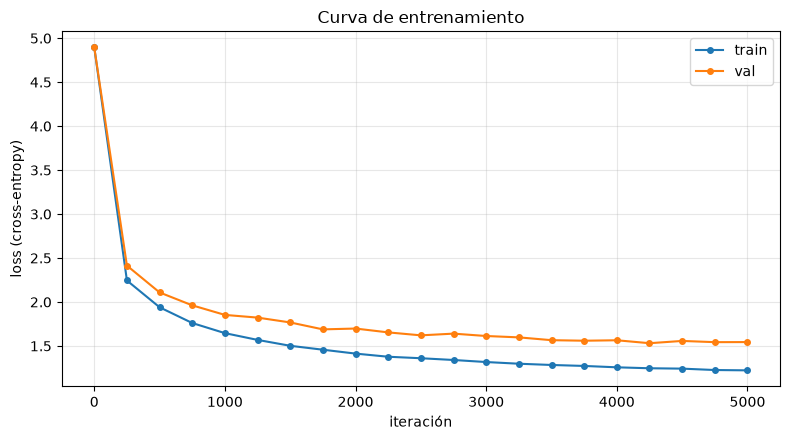

In [67]:
import matplotlib.pyplot as plt

def dibujar_curva(historial):
    if not historial:
        print("Ejecuta primero la celda de entrenamiento para llenar 'historial'.")
        return
    its   = [h[0] for h in historial]
    train = [h[1] for h in historial]
    val   = [h[2] for h in historial]
    plt.figure(figsize=(8, 4.5))
    plt.plot(its, train, marker="o", markersize=4, label="train")
    plt.plot(its, val,   marker="o", markersize=4, label="val")
    plt.xlabel("iteración")
    plt.ylabel("loss (cross-entropy)")
    plt.title("Curva de entrenamiento")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

dibujar_curva(historial)

## 15 · Generación DESPUÉS de entrenar

Ahora sí. El mismo modelo, los mismos pesos (ya entrenados), generando texto. Compáralo con la basura de la sección 13: el modelo ha aprendido ortografía, separación de palabras, puntuación, diálogos con guion y un estilo cervantino, **sin que nadie le enseñara ninguna regla explícita**. Todo eso emergió de minimizar una sola cosa: el error al predecir el siguiente carácter.


In [68]:
contexto = torch.zeros((1, 1), dtype=torch.long, device=device)
salida = model.generate(contexto, max_new_tokens=500, temperature=0.8, top_k=40)
print("--- Texto generado DESPUÉS de entrenar ---\n")
print(decode(salida[0].tolist()))

--- Texto generado DESPUÉS de entrenar ---


encima, aquí como se le tenía en su recauso, a su dueña del lugar cuantos los
eran algún gobierna de razón sostres que sucedió el nuestro día que estáballe el afrente
letrasentaron de este otra razón el de la sentir de la barba, sin los consejo que
en la mujer igualbra, el cual junto, dijo:

Alloraron se tal encendiga; y aun en quien tigo, el cual dijo que siente que te le he
considerado me de manera de Rocinante en él que a las tierras, que llevas los
acostumbres de poner el hide verdado para c


## 16 · Abrimos la caja negra: ¿qué ha aprendido el modelo?

Hasta aquí hemos tratado el modelo como una caja: entra texto, sale texto. Ahora vamos a **asomarnos dentro** de dos de sus módulos —la **atención** y los **embeddings**— para ver, literalmente, qué representaciones ha aprendido. Esto es, en miniatura, lo que se conoce como *interpretabilidad* de modelos.

> Estas celdas solo tienen sentido **después de entrenar**. Si las ejecutas con el modelo recién creado, verás ruido.


### 16.1 · Atención: ¿quién mira a quién?

Cada cabeza produjo una matriz de pesos T×T: la **fila _i_** indica cuánto atiende el token _i_ a cada token anterior. La dibujamos como un **mapa de calor**.

**Cómo leerlo:**
- Cada **fila** = un token *mirando* (su *query*); cada **columna** = un token *mirado* (su *key*).
- Cuanto **más brillante** la celda, más atención. El **triángulo superior derecho está oscuro** (≈ 0): es el futuro, prohibido por la máscara causal — por eso se ve la característica forma triangular.

Cambia la **capa** y la **cabeza** y compara: unas se especializan en el token anterior inmediato, otras en los espacios (inicios de palabra), otras en signos de puntuación. **Nadie se lo enseñó**: emergió del entrenamiento.


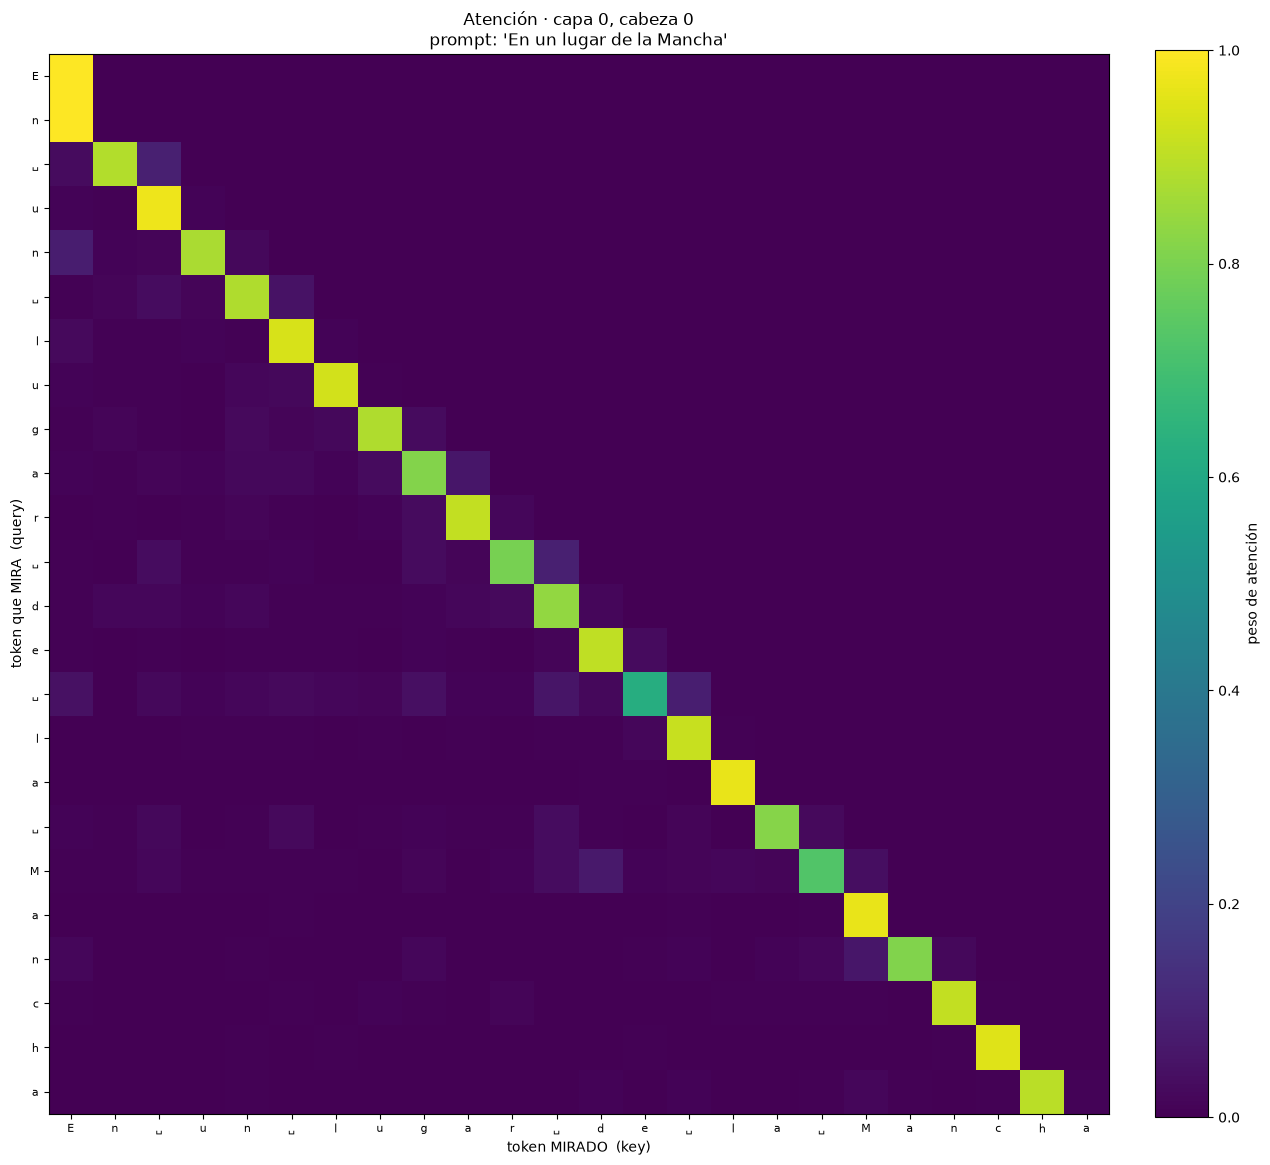

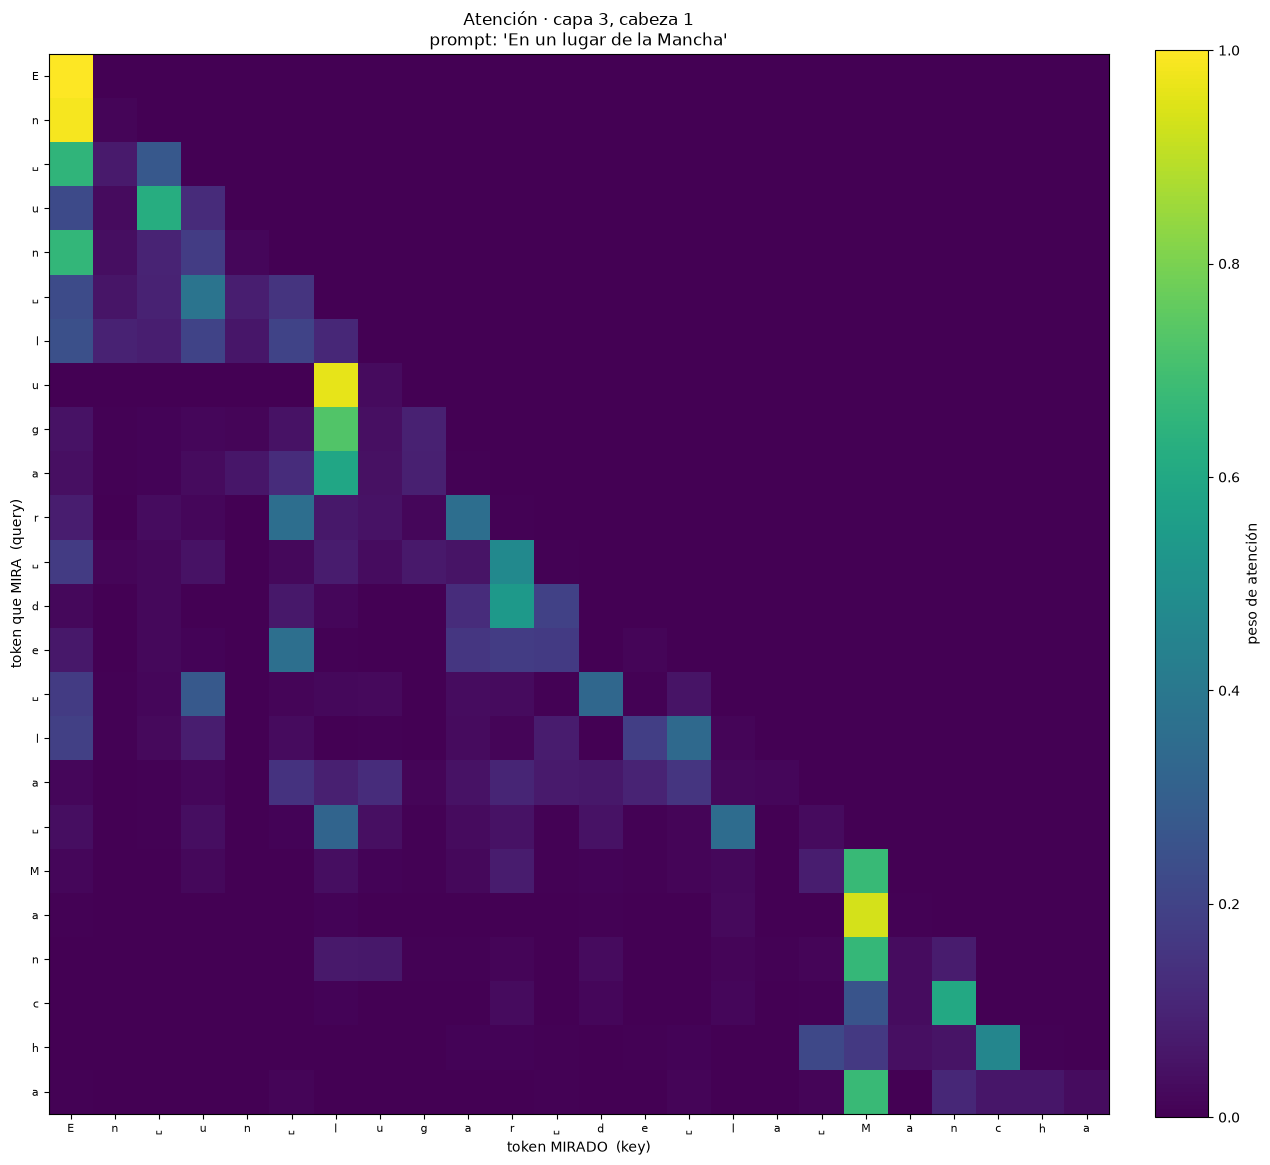

In [76]:
import matplotlib.pyplot as plt

def mostrar_atencion(prompt, capa=0, cabeza=0):
    model.eval()
    ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    with torch.no_grad():
        model(ids[:, -block_size:])               # un forward rellena Head.att en cada cabeza
    # .tolist() en vez de .numpy(): evita el puente PyTorch->NumPy (que falla si las
    # versiones de torch y numpy no son compatibles). imshow acepta listas sin problema.
    att = model.blocks[capa].sa.heads[cabeza].att[0].float().cpu().tolist()   # (T, T)
    etiquetas = [c.replace(" ", "␣").replace("\n", "⏎") for c in prompt]
    T = len(etiquetas)

    fig, ax = plt.subplots(figsize=(0.45 * T + 2, 0.45 * T + 1.5))
    im = ax.imshow(att, cmap="viridis", vmin=0)
    ax.set_xticks(range(T)); ax.set_xticklabels(etiquetas, fontsize=8)
    ax.set_yticks(range(T)); ax.set_yticklabels(etiquetas, fontsize=8)
    ax.set_xlabel("token MIRADO  (key)")
    ax.set_ylabel("token que MIRA  (query)")
    ax.set_title(f"Atención · capa {capa}, cabeza {cabeza}\nprompt: {prompt!r}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="peso de atención")
    plt.tight_layout()
    plt.show()

mostrar_atencion("En un lugar de la Mancha", capa=0, cabeza=0)
mostrar_atencion("En un lugar de la Mancha", capa=n_layer - 1, cabeza=1)

### 16.2 · Embeddings: los caracteres con un papel parecido acaban juntos

La tabla de *token embeddings* convirtió cada carácter en un vector. Durante el entrenamiento, los caracteres que aparecen en **contextos parecidos** (las vocales entre sí, los dígitos entre sí…) tienden a acabar con **vectores parecidos**. Medimos la similitud (coseno) entre embeddings y mostramos los *vecinos* más cercanos de algunos caracteres.

> Con un modelo pequeño y a nivel carácter las agrupaciones son sutiles, pero ya se intuyen. Es la misma idea por la que en modelos grandes *"rey" − "hombre" + "mujer" ≈ "reina"*: el significado vive en la **geometría** de los embeddings.


In [74]:
def vecinos(ch, k=6):
    E = model.token_emb.weight.detach().float()
    E = E / E.norm(dim=1, keepdim=True)          # normalizamos -> el producto escalar es el coseno
    sims = E @ E[stoi[ch]]
    vals, idx = sims.topk(k + 1)                  # +1 porque el primero es el propio carácter
    return [(itos[i.item()], v.item()) for v, i in zip(vals, idx) if i.item() != stoi[ch]][:k]

def mostrar_vecinos(ch):
    etq = repr(ch.replace(" ", "␣").replace("\n", "⏎"))
    pares = [f"{repr(c.replace(' ', '␣'))}({s:.2f})" for c, s in vecinos(ch)]
    print(f"  vecinos de {etq:>5}: " + ", ".join(pares))

print("Caracteres más parecidos según sus embeddings (similitud coseno):\n")
for c in ["a", "e", "o", "Q", "1", ".", " "]:
    mostrar_vecinos(c)

Caracteres más parecidos según sus embeddings (similitud coseno):

  vecinos de   'a': 's'(0.16), 'L'(0.16), 'à'(0.15), 'á'(0.13), 'O'(0.11), 't'(0.10)
  vecinos de   'e': '2'(0.15), '6'(0.13), 's'(0.13), 'W'(0.12), 'N'(0.12), '‘'(0.10)
  vecinos de   'o': 'u'(0.13), '"'(0.12), 'w'(0.10), 'ú'(0.10), '”'(0.10), ';'(0.09)
  vecinos de   'Q': '*'(0.13), '«'(0.12), 'á'(0.11), 'c'(0.10), 'ñ'(0.10), 'R'(0.09)
  vecinos de   '1': '2'(0.15), '»'(0.11), 'K'(0.11), 'q'(0.10), '¿'(0.10), 'k'(0.10)
  vecinos de   '.': 'h'(0.20), 'q'(0.14), '?'(0.12), '('(0.10), 'à'(0.10), '/'(0.09)
  vecinos de   '␣': 'W'(0.14), '?'(0.11), 'v'(0.10), '’'(0.10), 'n'(0.10), '2'(0.10)


## 17 · Jugando con los parámetros de inferencia

Estos son **los mismos parámetros que controlas en la API de cualquier LLM**. No cambian el modelo (los pesos están fijos): solo cambian *cómo elegimos* el siguiente token a partir de las probabilidades que el modelo predice. Ejecuta la celda varias veces y observa cómo cambia el resultado:

- **`temperature`** — "audacia" del muestreo. Baja (0.3) → texto conservador y repetitivo (elige casi siempre lo más probable). Alta (1.2) → creativo y caótico (se atreve con opciones improbables).
- **`top_k`** — solo considera los *k* tokens más probables y descarta el resto. Evita los disparates más raros.
- **`top_p`** (nucleus) — considera los tokens más probables hasta acumular probabilidad *p* (p. ej. 0.9). Como `top_k` pero adaptativo.

Justo debajo (17.1) hay una celda que **te enseña la distribución de probabilidad** sobre la que actúan estos parámetros; luego, en la celda final, los verás aplicados a generaciones completas.


### 17.1 · La temperatura, en directo: viendo la distribución

`temperature` **no cambia lo que el modelo sabe**; cambia cómo de *puntiaguda* es la distribución de probabilidad de la que muestreamos el siguiente carácter. Para un mismo contexto, mostramos los caracteres más probables con su probabilidad a distintas temperaturas:

- **Baja (0.3):** casi toda la probabilidad se concentra en una o dos opciones → texto seguro y repetitivo.
- **Alta (1.5):** la probabilidad se reparte entre muchas opciones → texto diverso y arriesgado.

Es exactamente la palanca que mueves con el parámetro `temperature` en la API de cualquier LLM, vista por dentro.


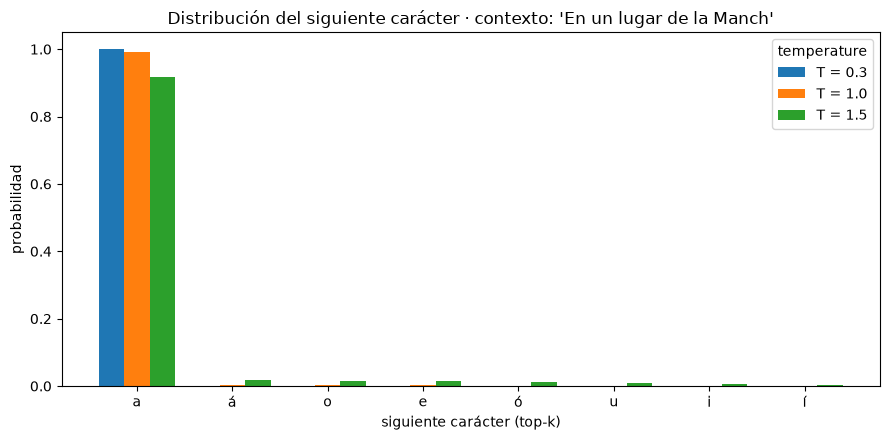

In [77]:
import matplotlib.pyplot as plt
import numpy as np

def barras_siguiente(prompt, temperaturas=(0.3, 1.0, 1.5), k=8):
    model.eval()
    ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    with torch.no_grad():
        logits, _ = model(ids[:, -block_size:])
    logits = logits[0, -1]
    # elegimos los k caracteres más probables (a T=1.0) como eje común de comparación
    _, topi = F.softmax(logits, dim=-1).topk(k)
    labels = [itos[i.item()].replace(" ", "␣").replace("\n", "⏎") for i in topi]

    x = np.arange(k)
    w = 0.8 / len(temperaturas)
    plt.figure(figsize=(9, 4.5))
    for j, t in enumerate(temperaturas):
        # .tolist() en vez de .numpy(): evita el puente PyTorch->NumPy
        probs = F.softmax(logits / t, dim=-1)[topi].cpu().tolist()
        plt.bar(x + j * w, probs, width=w, label=f"T = {t}")
    plt.xticks(x + w * (len(temperaturas) - 1) / 2, labels)
    plt.xlabel("siguiente carácter (top-k)")
    plt.ylabel("probabilidad")
    plt.title(f"Distribución del siguiente carácter · contexto: {prompt!r}")
    plt.legend(title="temperature")
    plt.tight_layout()
    plt.show()

# Mismo contexto, misma red: T baja concentra la probabilidad; T alta la reparte
barras_siguiente("En un lugar de la Manch")

In [78]:
def generar(prompt="", n=300, temperature=0.8, top_k=None, top_p=None):
    if prompt:
        idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    else:
        idx = torch.zeros((1, 1), dtype=torch.long, device=device)
    out = model.generate(idx, max_new_tokens=n, temperature=temperature,
                         top_k=top_k, top_p=top_p)
    return decode(out[0].tolist())

print("### temperature = 0 (conservador) ###")
print(generar("En un lugar de la Mancha, de cuyo", n=300, temperature=0.01), "\n")

print("### temperature = 1.2 (creativo) ###")
print(generar("En un lugar de la Mancha, de cuyo", n=300, temperature=1.2), "\n")

print("### top_p = 0.9 (nucleus sampling) ###")
print(generar("En un lugar de la Mancha, de cuyo", n=300, temperature=0.9, top_p=0.9))

### temperature = 0 (conservador) ###
En un lugar de la Mancha, de cuyo de la cabeza de la cabeza de la cabeza, y
de la cual se le había de hacer en el mundo de la cabeza de la cabeza de la
primera de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza, y
así como la había de ser con la cabeza de la cabeza de la cabeza de la cabeza, y así,
por lo que se le ha 

### temperature = 1.2 (creativo) ###
En un lugar de la Mancha, de cuyo
era, padere de las gatanas.
Mas, en lo que te, habiéndole, o ¡Gallándose de tal, que quisiere tan
gente gran herida, me puntamente el diego,
o a hacer de imágina y lo que replique fraginación, y la usla infielsa que ahuria en
mí con él dice una quiere aquella otra viverida deda, españóles os honrad 

### top_p = 0.9 (nucleus sampling) ###
En un lugar de la Mancha, de cuyo muy grandeza muy bien
hombres que cuán esperaban para dar su parte. Digo esto dijo:

— Si no lo que ninguna encantada, ni hay en qué tengo de servido, ni como son las
obras que le 

## 18 · Lo que acabas de hacer

Has construido y entrenado un **modelo de lenguaje generativo completo** desde cero:

- **Tokenización** y preparación de datos (y por qué carácter vs BPE).
- La **arquitectura Transformer** entera: atención causal, multi-head, feed-forward, residuales, LayerNorm.
- El **bucle de entrenamiento** por descenso de gradiente, y qué significa la *loss*.
- Una mirada **dentro** del modelo: mapas de atención y geometría de los embeddings.
- La **generación autoregresiva** con `temperature`, `top_k` y `top_p`.

Es **exactamente** el mismo principio que hay detrás de ChatGPT. La diferencia es de escala: más datos, más parámetros, más cómputo. Pero la naturaleza del proceso es la que acabas de ver con tus propios ojos.

> Si entiendes lo que entrena este mini-GPT, entiendes lo que entrena GPT-4.

### Conexión final: de este mini-GPT a GPT-4

Recuerda lo que vimos en la sección 5. **Para pasar de tokenización por carácter a BPE (la de GPT real), solo cambiarías las funciones `encode`/`decode` y el valor de `vocab_size`.** Toda la arquitectura, el entrenamiento y la generación de este notebook quedarían **idénticos**. Lo que separa a este modelo de GPT-4 no es *cómo* funciona, sino *cuánto*: vocabulario, contexto, parámetros, datos y cómputo.

### Ideas para experimentar

- Entrena más iteraciones (`max_iters`) y observa si la val loss sigue bajando o el modelo sobreajusta.
- Cambia el corpus: prueba con otro libro, letras de canciones o incluso código fuente.
- Aumenta `n_layer` / `n_embed` y mide el efecto en la loss y el tiempo de entrenamiento.
- Explora la atención: cambia el `prompt`, la `capa` y la `cabeza` en `mostrar_atencion` y busca cabezas con patrones claros (token anterior, espacios, puntuación).
- Instala `tiktoken` y reescribe `encode`/`decode` con BPE: comprobarás que **el resto del notebook no necesita cambios**.
- Guarda el modelo con `torch.save(model.state_dict(), "minigpt.pt")` y recárgalo más tarde.


## 19 · Cómo podríamos mejorar este mini-GPT

Lo que has construido es un GPT **completo pero minúsculo**. Si quisieras acercarlo a un modelo "de verdad", estos son los ejes por los que se empuja en la práctica. No hace falta aplicarlos todos: las celdas siguientes ilustran los dos patrones más representativos (uno de arquitectura, otro de entrenamiento).

**Arquitectura**
- **Weight tying** — compartir los pesos del embedding de entrada (`token_emb`) y de la cabeza de salida (`head`). Reduce parámetros y suele mejorar la calidad; lo usan GPT-2/3. _(demo en 19.1)_
- **GELU en vez de ReLU** — la activación de los GPT reales, más suave. Es cambiar `nn.ReLU()` por `nn.GELU()` en `FeedForward`.
- **Atención optimizada** — `F.scaled_dot_product_attention` (Flash Attention) calcula lo mismo que nuestra `Head`, pero mucho más rápido y con menos memoria.
- **Más escala** — subir `n_layer`, `n_embed` y `block_size`. Es la palanca nº 1, pero la que más cómputo cuesta.

**Entrenamiento**
- **Calendario de learning rate** — *warmup* lineal al principio + decaimiento *coseno* al final, en lugar de LR constante. Estabiliza el arranque y afina el cierre. _(gráfica en 19.2)_
- **Gradient clipping** — `torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)` evita pasos catastróficos.
- **Precisión mixta** — `torch.autocast` entrena en bf16/fp16: ~2× más rápido en GPU.
- **Más iteraciones y más datos**, vigilando siempre la curva de validación para no sobreajustar.

**Datos y tokenización**
- **Tokenización BPE** en lugar de carácter (recuerda la sección 5): mismo modelo, `encode`/`decode` distintos; secuencias más cortas y más "significado" por token.
- **Mejor corpus**: más texto, más variado y mejor limpiado (en *Don Quijote* arrastramos la cabecera de Project Gutenberg, por ejemplo).

**De "modelo base" a asistente** *(lo más relevante para un máster en IA agéntica)*
Nuestro modelo es un **modelo base**: solo sabe *continuar* texto. Para convertirlo en un asistente que sigue instrucciones (lo que diferencia a GPT-4 de un modelo base) faltarían dos fases más, **sobre esta misma arquitectura**:
1. **SFT (Supervised Fine-Tuning)** — seguir entrenando con ejemplos de `instrucción → respuesta`.
2. **Alineamiento (RLHF / DPO)** — ajustar el modelo con preferencias humanas para que sea útil, honesto e inofensivo.

El *pre-entrenamiento* que acabas de hacer es la base sobre la que se montan esas fases. **Misma red; distinto objetivo de datos.**


### 19.1 · Mejora de arquitectura: *weight tying*

El embedding de entrada y la cabeza de salida tienen **exactamente la misma forma** (`vocab_size × n_embed`). Atarlos —compartir el mismo tensor de pesos— ahorra parámetros y, en la práctica, mejora la calidad. Veamos cuánto ahorraríamos en nuestro modelo:


In [79]:
params_emb = vocab_size * n_embed
total = sum(p.numel() for p in model.parameters())

print(f"token_emb (embedding de entrada): {params_emb:,} parámetros")
print(f"head      (cabeza de salida):     {params_emb:,} parámetros  (misma forma)")
print(f"\nCon weight tying compartiríamos ese tensor -> ahorro de {params_emb:,} parámetros")
print(f"Sobre los {total:,} del modelo, es un {params_emb / total * 100:.1f}% menos.")
print("\nImplementación: una sola línea al final de MiniGPT.__init__")
print("    self.head.weight = self.token_emb.weight")

token_emb (embedding de entrada): 28,160 parámetros
head      (cabeza de salida):     28,160 parámetros  (misma forma)

Con weight tying compartiríamos ese tensor -> ahorro de 28,160 parámetros
Sobre los 3,245,678 del modelo, es un 0.9% menos.

Implementación: una sola línea al final de MiniGPT.__init__
    self.head.weight = self.token_emb.weight


### 19.2 · Mejora de entrenamiento: *warmup* + decaimiento coseno

En vez de un learning rate constante, los GPT reales empiezan con un *warmup* lineal (subir despacio para no desestabilizar los primeros pasos) y luego lo bajan suavemente con una curva coseno (afinar al final). Así se vería aplicado a nuestras `max_iters`:


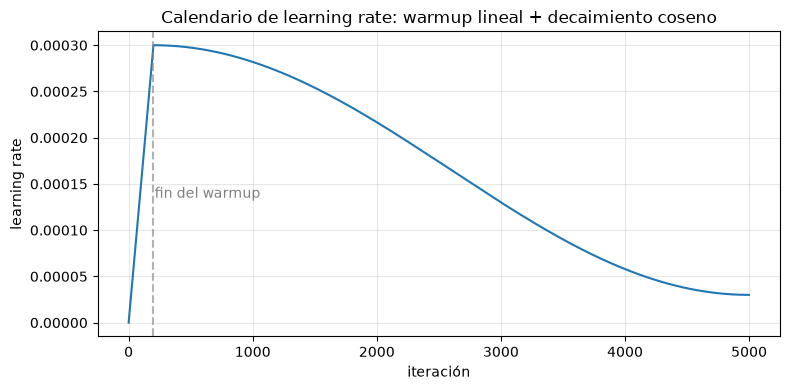

Se conecta al optimizador con torch.optim.lr_scheduler.LambdaLR(optimizer, factor_lr)
y llamando scheduler.step() después de cada optimizer.step().


In [80]:
import math
import matplotlib.pyplot as plt

warmup    = min(200, max(1, max_iters // 10))   # 200 pasos de calentamiento (o 10% si max_iters es pequeño)
min_ratio = 0.1                                 # el LR baja hasta el 10% del valor inicial

def factor_lr(it):
    if it < warmup:                             # 1) warmup lineal: 0 -> 1
        return it / warmup
    prog = (it - warmup) / max(1, max_iters - warmup)   # 2) decaimiento coseno: 1 -> min_ratio
    return min_ratio + (1 - min_ratio) * 0.5 * (1 + math.cos(math.pi * prog))

its = list(range(max_iters))
lrs = [learning_rate * factor_lr(i) for i in its]

plt.figure(figsize=(8, 4))
plt.plot(its, lrs)
plt.axvline(warmup, color="gray", linestyle="--", alpha=0.6)
plt.text(warmup * 1.05, max(lrs) * 0.45, "fin del warmup", color="gray")
plt.xlabel("iteración")
plt.ylabel("learning rate")
plt.title("Calendario de learning rate: warmup lineal + decaimiento coseno")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Se conecta al optimizador con torch.optim.lr_scheduler.LambdaLR(optimizer, factor_lr)")
print("y llamando scheduler.step() después de cada optimizer.step().")